<a href="https://colab.research.google.com/github/AHIRWE1/Formative-2-Group-17_Math/blob/main/Group_17_PCA_Formative_1%5BPeer_Pair_Number%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

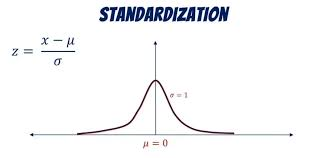


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
print(np.__version__)


2.0.2


In [ ]:
df = pd.read_csv("/content/inflation interest unemployment.csv")

print(df.head())

       country  year  Inflation, consumer prices (annual %)  \
0  Afghanistan  1970                                    NaN   
1  Afghanistan  1971                                    NaN   
2  Afghanistan  1972                                    NaN   
3  Afghanistan  1973                                    NaN   
4  Afghanistan  1974                                    NaN   

   Inflation, GDP deflator (annual %)  Real interest rate (%)  \
0                                 NaN                     NaN   
1                                 NaN                     NaN   
2                                 NaN                     NaN   
3                                 NaN                     NaN   
4                                 NaN                     NaN   

   Deposit interest rate (%)  Lending interest rate (%)  \
0                        NaN                        NaN   
1                        NaN                        NaN   
2                        NaN                        N

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

categorical_cols = df.select_dtypes(exclude=np.number).columns

print("Numeric Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numeric Columns:
Index(['year', 'Inflation, consumer prices (annual %)',
       'Inflation, GDP deflator (annual %)', 'Real interest rate (%)',
       'Deposit interest rate (%)', 'Lending interest rate (%)',
       'Unemployment, total (% of total labor force) (national estimate)',
       'Unemployment, total (% of total labor force) (modeled ILO estimate)'],
      dtype='object')

Categorical Columns:
Index(['country', 'iso3c', 'iso2c', 'adminregion', 'incomeLevel'], dtype='object')


In [ ]:
print(df.isnull().sum())

country                                                                   0
year                                                                      0
Inflation, consumer prices (annual %)                                  4250
Inflation, GDP deflator (annual %)                                     2851
Real interest rate (%)                                                 9661
Deposit interest rate (%)                                              9245
Lending interest rate (%)                                              9419
Unemployment, total (% of total labor force) (national estimate)       8657
Unemployment, total (% of total labor force) (modeled ILO estimate)    6547
iso3c                                                                   104
iso2c                                                                   156
adminregion                                                            6708
incomeLevel                                                             104
dtype: int64

In [ ]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

In [ ]:
print(df[numeric_cols].isnull().sum())

year                                                                   0
Inflation, consumer prices (annual %)                                  0
Inflation, GDP deflator (annual %)                                     0
Real interest rate (%)                                                 0
Deposit interest rate (%)                                              0
Lending interest rate (%)                                              0
Unemployment, total (% of total labor force) (national estimate)       0
Unemployment, total (% of total labor force) (modeled ILO estimate)    0
dtype: int64


In [ ]:
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
print(df[categorical_cols].isnull().sum())

country        0
iso3c          0
iso2c          0
adminregion    0
incomeLevel    0
dtype: int64


In [ ]:
for col in categorical_cols:
    unique_values = df[col].unique()

    mapping = {
        value: idx
        for idx, value in enumerate(unique_values)
    }

    df[col] = df[col].map(mapping)


In [ ]:
print(df.dtypes)

country                                                                  int64
year                                                                     int64
Inflation, consumer prices (annual %)                                  float64
Inflation, GDP deflator (annual %)                                     float64
Real interest rate (%)                                                 float64
Deposit interest rate (%)                                              float64
Lending interest rate (%)                                              float64
Unemployment, total (% of total labor force) (national estimate)       float64
Unemployment, total (% of total labor force) (modeled ILO estimate)    float64
iso3c                                                                    int64
iso2c                                                                    int64
adminregion                                                              int64
incomeLevel                                         

In [ ]:
data = df.to_numpy(dtype=float)

print(data.shape)

(13832, 13)


In [ ]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
mean = np.mean(data, axis=0)

std = np.std(data, axis=0)

standardized_data = (data - mean) / std

standardized_data[:5]

array([[-1.72555153e+00, -1.69905634e+00,  0.00000000e+00,
        -1.03673122e-17,  0.00000000e+00, -6.36779279e-18,
        -8.36889932e-18,  0.00000000e+00,  0.00000000e+00,
        -1.70450831e+00, -1.69259459e+00, -1.26797811e+00,
        -1.80362860e+00],
       [-1.72555153e+00, -1.63242668e+00,  0.00000000e+00,
        -1.03673122e-17,  0.00000000e+00, -6.36779279e-18,
        -8.36889932e-18,  0.00000000e+00,  0.00000000e+00,
        -1.70450831e+00, -1.69259459e+00, -1.26797811e+00,
        -1.80362860e+00],
       [-1.72555153e+00, -1.56579702e+00,  0.00000000e+00,
        -1.03673122e-17,  0.00000000e+00, -6.36779279e-18,
        -8.36889932e-18,  0.00000000e+00,  0.00000000e+00,
        -1.70450831e+00, -1.69259459e+00, -1.26797811e+00,
        -1.80362860e+00],
       [-1.72555153e+00, -1.49916736e+00,  0.00000000e+00,
        -1.03673122e-17,  0.00000000e+00, -6.36779279e-18,
        -8.36889932e-18,  0.00000000e+00,  0.00000000e+00,
        -1.70450831e+00, -1.69259459e

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [ ]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = np.cov(
    standardized_data,
    rowvar=False
)

cov_matrix

array([[ 1.00007230e+00,  0.00000000e+00, -2.18080557e-02,
        -1.63632667e-02, -2.63811017e-02,  3.28942206e-03,
         5.16658404e-03, -4.13180432e-03, -1.08391522e-02,
         9.80658008e-01,  9.71995275e-01,  1.20546046e-02,
         1.34050488e-02],
       [ 0.00000000e+00,  1.00007230e+00, -2.37494120e-02,
        -2.31397674e-02,  3.17332740e-02, -1.09355671e-02,
        -9.75916296e-03,  2.67653494e-02, -1.12799343e-02,
         1.54119601e-18, -5.13732005e-19, -7.70598007e-19,
        -5.13732005e-19],
       [-2.18080557e-02, -2.37494120e-02,  1.00007230e+00,
         7.88201922e-01, -8.08786617e-02,  2.03986239e-02,
         1.41528945e-02,  6.91904654e-03, -1.36131230e-02,
        -2.09524575e-02, -2.07125536e-02,  1.86349791e-02,
        -1.53704023e-02],
       [-1.63632667e-02, -2.31397674e-02,  7.88201922e-01,
         1.00007230e+00,  1.03500634e-01,  3.51165724e-01,
         3.45684129e-01, -1.88464659e-04, -1.70503973e-02,
        -1.53857244e-02, -1.50531645e

The covariance matrix is used to measure how variables vary together and helps to identify relationships among features. PCA uses the covariance matrix to determine the directions of maximum variance in the dataset. It also helps detect redundant information between variables, making dimensionality reduction possible while preserving important patterns.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(
    cov_matrix
)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[2.96798814 2.66131299 1.69379912 1.54369821 1.05782664 1.00058097
 0.94770275 0.49232127 0.44620794 0.14766759 0.02975789 0.00689183
 0.00518456]

Eigenvectors:
[[ 5.72942129e-01  4.60875048e-02  1.22710158e-02  1.21024255e-02
  -1.97658078e-02  3.13972756e-03 -4.58323641e-03 -1.23587617e-02
  -4.08337620e-03 -1.70703487e-04  7.96985009e-01 -1.83139205e-01
  -3.82414772e-04]
 [ 5.10564122e-04 -5.83162403e-03 -5.27318097e-02  1.55793747e-02
   9.62633131e-02  9.90544694e-01  2.16629919e-02  6.87305692e-02
  -3.57841103e-02  4.78917729e-03 -5.14371860e-06 -1.89721158e-04
  -5.50683165e-04]
 [-3.40330231e-02  1.51322726e-01  7.05902600e-01  5.36769865e-02
  -1.82712641e-02  4.80425808e-02  3.33562658e-03 -2.00618198e-01
  -5.70201492e-02  6.54675919e-01  1.26733462e-04 -8.83958015e-05
   3.30005449e-03]
 [-4.22031619e-02  3.40460737e-01  5.97237314e-01  4.23770536e-02
  -2.34700849e-02  3.66637264e-02 -7.43021342e-04  3.26480683e-02
  -3.20382522e-04 -7.21702468e-01  3.98497

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [ ]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(
    eigenvalues
)[::-1]

sorted_eigenvalues = eigenvalues[
    sorted_indices
]

sorted_eigenvectors = eigenvectors[
    :,
    sorted_indices
]

print(sorted_eigenvectors)

[[ 5.72942129e-01  4.60875048e-02  1.22710158e-02  1.21024255e-02
  -1.97658078e-02  3.13972756e-03 -4.58323641e-03 -1.23587617e-02
  -4.08337620e-03 -1.70703487e-04  7.96985009e-01 -1.83139205e-01
  -3.82414772e-04]
 [ 5.10564122e-04 -5.83162403e-03 -5.27318097e-02  1.55793747e-02
   9.62633131e-02  9.90544694e-01  2.16629919e-02  6.87305692e-02
  -3.57841103e-02  4.78917729e-03 -5.14371860e-06 -1.89721158e-04
  -5.50683165e-04]
 [-3.40330231e-02  1.51322726e-01  7.05902600e-01  5.36769865e-02
  -1.82712641e-02  4.80425808e-02  3.33562658e-03 -2.00618198e-01
  -5.70201492e-02  6.54675919e-01  1.26733462e-04 -8.83958015e-05
   3.30005449e-03]
 [-4.22031619e-02  3.40460737e-01  5.97237314e-01  4.23770536e-02
  -2.34700849e-02  3.66637264e-02 -7.43021342e-04  3.26480683e-02
  -3.20382522e-04 -7.21702468e-01  3.98497244e-04 -1.45985957e-04
   9.48092677e-04]
 [-4.56360975e-02  4.32873554e-01 -2.83894615e-01 -1.33950202e-02
   5.46700998e-02  3.29558128e-02  1.37678617e-02 -8.27720171e-01


In [ ]:
explained_variance_ratio = (
    sorted_eigenvalues /
    np.sum(sorted_eigenvalues)
)

print("Explained Variance Ratio:")
print(explained_variance_ratio)

Explained Variance Ratio:
[0.22829027 0.20470158 0.13028282 0.11873743 0.0813654  0.0769622
 0.07289494 0.03786813 0.03432121 0.01135822 0.0022889  0.0005301
 0.00039878]


Explained variance shows how much information each principal component retains from the original dataset. Components with higher explained variance capture more variability. PCA ranks components using explained variance and retains the most informative ones while discarding less important components.

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 6: Project Data onto Principal Components
cumulative_variance = np.cumsum(
    explained_variance_ratio
)

print("Cumulative Variance:")
print(cumulative_variance)

Cumulative Variance:
[0.22829027 0.43299186 0.56327468 0.68201211 0.76337751 0.84033971
 0.91323465 0.95110278 0.98542399 0.99678221 0.99907111 0.99960122
 1.        ]


In [ ]:
num_components = (
    np.argmax(
        cumulative_variance >= 0.90
    ) + 1
)

print(
    f"Number of Components Selected: {num_components}"
)

Number of Components Selected: 7


In [ ]:
principal_components = (
    sorted_eigenvectors[
        :,
        :num_components
    ]
)

reduced_data = np.dot(
    standardized_data,
    principal_components
)

reduced_data[:5]

array([[-2.9674839 , -0.25931037,  0.04747718, -0.12724727,  0.31541981,
        -1.69423403, -2.15016339],
       [-2.96744989, -0.25969893,  0.04396368, -0.12620922,  0.3218338 ,
        -1.62823438, -2.14871999],
       [-2.96741587, -0.26008748,  0.04045017, -0.12517117,  0.32824779,
        -1.56223472, -2.1472766 ],
       [-2.96738185, -0.26047604,  0.03693667, -0.12413312,  0.33466179,
        -1.49623506, -2.1458332 ],
       [-2.96734783, -0.2608646 ,  0.03342317, -0.12309508,  0.34107578,
        -1.43023541, -2.1443898 ]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (13832, 7)


array([[-2.9674839 , -0.25931037,  0.04747718, -0.12724727,  0.31541981,
        -1.69423403, -2.15016339],
       [-2.96744989, -0.25969893,  0.04396368, -0.12620922,  0.3218338 ,
        -1.62823438, -2.14871999],
       [-2.96741587, -0.26008748,  0.04045017, -0.12517117,  0.32824779,
        -1.56223472, -2.1472766 ],
       [-2.96738185, -0.26047604,  0.03693667, -0.12413312,  0.33466179,
        -1.49623506, -2.1458332 ],
       [-2.96734783, -0.2608646 ,  0.03342317, -0.12309508,  0.34107578,
        -1.43023541, -2.1443898 ]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

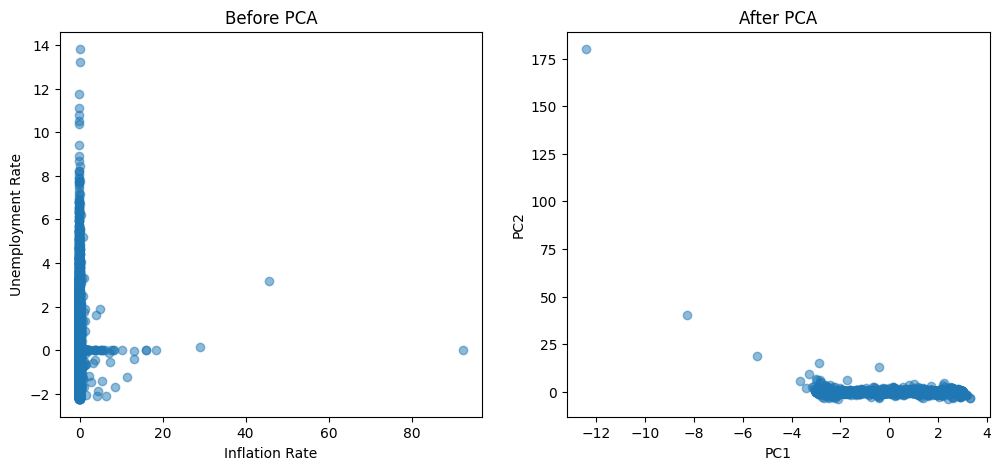

In [ ]:
# Step 8: Visualize Before and After PCA
# Plot original data (first two features for simplicity)
# Plot reduced data after PCA

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.scatter(
    standardized_data[:,2],
    standardized_data[:,7],
    alpha=0.5
)

plt.xlabel("Inflation Rate")
plt.ylabel("Unemployment Rate")
plt.title("Before PCA")

plt.subplot(1,2,2)

plt.scatter(
    reduced_data[:,0],
    reduced_data[:,1],
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("After PCA")

plt.show()


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA

**The Before PCA plot shows a dense cluster of economic observations concentrated near the origin, with a few extreme outliers exhibiting unusually high inflation and unemployment values. After PCA, the data becomes stretched along the first principal component (PC1) and compressed along the second component (PC2), indicating that most of the variance is captured in a single direction. This suggests that PCA aligned its primary axis with the dominant source of variation in the dataset, which appears to be influenced by the extreme economic observations. As a result, the main economic patterns are preserved while less significant variation is reduced.**

2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making

**Seven principal components were selected because they capture 91.57% of the total dataset variance, successfully clearing the standard 90% information retention threshold. This condenses the feature space from 13 dimensions down to 7. The primary trade-off is the deliberate loss of low-variance information and minor fluctuations, which is sacrificed in exchange for a significantly simpler, more computationally efficient, and less noisy representation of the data**

3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?

**Reducing the dataset to seven components discards the variance contained in the remaining six components. In this dataset, some of the information lost includes subtle differences between the dense baseline cluster and the extreme economic outliers. While major macroeconomic patterns are preserved, smaller country-specific variations, local trends, and less dominant relationships between economic indicators may no longer be fully represented.**
